In [1]:
!pip install segmentation-models-pytorch albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.4 MB/s eta 0:00:00


In [2]:
import os, re, copy, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

CFG = {
    # ── Data ──────────────────────────────────────────────────────────────
    "root"           : "/kaggle/input/datasets/mohamedbenticha/cbis-ddsm/DATA",
    "abnormality"    : "Mass",     # switch to "Calc" to train the other model
    "save_path"      : "/kaggle/working/mass_best_model.pth",

    # ── Training phases ───────────────────────────────────────────────────
    "warmup_epochs"  : 15,         # encoder frozen
    "finetune_epochs": 45,         # encoder unfrozen, lower LR

    # ── Optimiser ─────────────────────────────────────────────────────────
    "lr_head"        : 5e-4,       # decoder + classification head
    "lr_encoder"     : 2e-5,       # encoder during fine-tune phase
    "weight_decay"   : 1e-4,

    # ── Loss weights ──────────────────────────────────────────────────────
    "lambda_seg"     : 0.5,
    "lambda_cls"     : 0.5,

    # ── DataLoader ────────────────────────────────────────────────────────
    "batch_size"     : 32,          # reduce to 4 if OOM
    "num_workers"    : 4,
    "seed"           : 42,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG["seed"])


Device : cuda


In [3]:
IMG_SIZE   = 320
VALID_EXTS = {".png", ".jpg", ".jpeg", ".tiff"}
_KEY_RE    = re.compile(r"^(.*?)(_FULL|_MASK).*$", re.IGNORECASE)

def _extract_key(stem):
    m = _KEY_RE.match(stem)
    return m.group(1) if m else None

def _file_type(stem):
    m = _KEY_RE.match(stem)
    return m.group(2).lstrip("_").upper() if m else "UNKNOWN"

def _scan_folder(folder, label, abnormality, split):
    rows = []
    for fpath in sorted(Path(folder).iterdir()):
        if fpath.suffix.lower() not in VALID_EXTS:
            continue
        stem = fpath.stem
        rows.append({
            "path"       : str(fpath),
            "stem"       : stem,
            "key"        : _extract_key(stem),
            "file_type"  : _file_type(stem),
            "label"      : label,
            "label_name" : "BENIGN" if label == 0 else "MALIGNANT",
            "abnormality": abnormality,
            "split"      : split,
        })
    return pd.DataFrame(rows)

def build_pairs_dataframe(root, abnormality, split):
    """
    Returns a DataFrame with one row per matched (image, mask) pair.
    Columns: key, image_path, mask_path, label, label_name, abnormality, split
    Unmatched files are printed as warnings and excluded.
    """
    frames = []
    for label_name, label_idx in [("BENIGN", 0), ("MALIGNANT", 1)]:
        folder = Path(root) / abnormality / split / label_name
        if not folder.exists():
            print(f"[WARN] Not found: {folder}")
            continue
        frames.append(_scan_folder(folder, label_idx, abnormality, split))

    if not frames:
        raise FileNotFoundError(f"No folders found under {root}/{abnormality}/{split}/")

    df_all = pd.concat(frames, ignore_index=True)

    # Warn about files where pattern didn't match
    unknown = df_all[df_all["key"].isna()]
    if len(unknown):
        print(f"[WARN] {len(unknown)} files with no _FULL/_MASK — skipped")
    df_all = df_all[df_all["key"].notna()].copy()

    df_full = df_all[df_all["file_type"] == "FULL"].rename(columns={"path": "image_path"})
    df_mask = df_all[df_all["file_type"] == "MASK"].rename(columns={"path": "mask_path"})

    # Outer merge so orphans surface as NaN rows
    df_pairs = pd.merge(
        df_full[["key", "image_path", "label", "label_name", "abnormality", "split"]],
        df_mask[["key", "label", "mask_path"]],
        on=["key", "label"],
        how="outer",
    )

    no_image = df_pairs["image_path"].isna()
    no_mask  = df_pairs["mask_path"].isna()

    if no_image.any():
        print(f"[WARN] {no_image.sum()} MASK(s) with no matching FULL image:")
        for _, r in df_pairs[no_image].iterrows():
            print(f"       key={r['key']}")
    if no_mask.any():
        print(f"[WARN] {no_mask.sum()} FULL image(s) with no matching MASK:")
        for _, r in df_pairs[no_mask].iterrows():
            print(f"       key={r['key']}")

    df_pairs = df_pairs[~no_image & ~no_mask].reset_index(drop=True)

    n_b = (df_pairs["label"] == 0).sum()
    n_m = (df_pairs["label"] == 1).sum()
    print(f"[{abnormality}/{split}]  {len(df_pairs)} pairs  ({n_b} benign, {n_m} malignant)")
    return df_pairs

In [4]:
def get_train_transforms():
    return A.Compose([
        # No A.Resize needed — already done during caching
        A.HorizontalFlip(p=0.5),
        #A.VerticalFlip(p=0.3),
        #A.RandomRotate90(p=0.5),
        A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.GaussianBlur(blur_limit=3, p=1.0),
        ], p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        #A.CLAHE(clip_limit=4.0, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_val_transforms():
    return A.Compose([
        # No A.Resize needed — already done during caching
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

class CBISDDSMDataset(Dataset):
    def __init__(self, df_pairs, transforms=None, augment_fraction=0.0):
        self.df               = df_pairs.reset_index(drop=True)
        self.transforms       = transforms
        self.augment_fraction = augment_fraction
        self.augmentor        = A.Compose([
            A.HorizontalFlip(p=0.5),
            #A.VerticalFlip(p=0.3),
            #A.RandomRotate90(p=0.5),
            A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
            A.OneOf([
                A.GaussNoise(p=1.0),
                A.GaussianBlur(blur_limit=3, p=1.0),
            ], p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
           # A.CLAHE(clip_limit=4.0, p=0.3),
        ])
        # Pre-shuffle which indices get augmented — reshuffled each epoch
        self._augment_flags = self._new_augment_flags()

    def _new_augment_flags(self):
        n       = len(self.df)
        flags   = np.zeros(n, dtype=bool)
        n_aug   = int(n * self.augment_fraction)
        indices = np.random.choice(n, size=n_aug, replace=False)
        flags[indices] = True
        return flags

    def reshuffle_augmentation(self):
        self._augment_flags = self._new_augment_flags()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = np.load(row["image_path"])
        mask  = np.load(row["mask_path"])

        if self.augment_fraction > 0 and self._augment_flags[idx]:
            out   = self.augmentor(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]

        if self.transforms:
            out   = self.transforms(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"].unsqueeze(0)
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask  = torch.from_numpy(mask).unsqueeze(0)

        return image, mask, torch.tensor(row["label"], dtype=torch.long)

In [12]:
class SegmentationUNet(nn.Module):
    def __init__(self, encoder_name="mit_b2", encoder_weights="imagenet",
                 freeze_encoder=True):
        super().__init__()
        self.unet = smp.UnetPlusPlus(
            encoder_name="efficientnet-b4",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None,
            decoder_channels=(128, 64, 32, 16, 8),  # was (256, 128, 64, 32, 16)
            decoder_attention_type=None,             # remove scse attention
        )
        if freeze_encoder:
            self.freeze_encoder()

    def freeze_encoder(self):
        for p in self.unet.encoder.parameters():
            p.requires_grad = False
        print("[Model] Encoder FROZEN")

    def unfreeze_encoder(self):
        for p in self.unet.encoder.parameters():
            p.requires_grad = True
        print("[Model] Encoder UNFROZEN — fine-tuning end-to-end")

    def forward(self, x):
        features    = self.unet.encoder(x)
        decoder_out = self.unet.decoder(features)
        seg_logit   = self.unet.segmentation_head(decoder_out)
        return seg_logit

In [6]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits)
        probs   = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        inter   = (probs * targets).sum(dim=1)
        dice    = (2.0 * inter + self.smooth) / (probs.sum(dim=1) + targets.sum(dim=1) + self.smooth)
        return 1.0 - dice.mean()

class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, pos_weight=10.0):
        super().__init__()
        self.dice       = DiceLoss()
        self.dw         = dice_weight
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        # Create pos_weight tensor on same device as logits
        pw       = torch.tensor([self.pos_weight], device=logits.device)
        bce_loss = nn.BCEWithLogitsLoss(pos_weight=pw)(logits, targets)
        return self.dw * self.dice(logits, targets) + (1 - self.dw) * bce_loss

criterion = DiceBCELoss(dice_weight=0.5, pos_weight=20.0)

def dice_score(seg_logit, mask_target, threshold=0.5, smooth=1.0):
    with torch.no_grad():
        probs   = torch.sigmoid(seg_logit)
        preds   = (probs > threshold).float()
        preds   = preds.view(preds.size(0), -1)
        targets = mask_target.view(mask_target.size(0), -1)
        inter   = (preds * targets).sum(dim=1)
        dice    = (2 * inter + smooth) / (preds.sum(dim=1) + targets.sum(dim=1) + smooth)
        return dice.mean().item()



In [7]:
df_train = build_pairs_dataframe(CFG["root"], CFG["abnormality"], split="Train")
df_test  = build_pairs_dataframe(CFG["root"], CFG["abnormality"], split="Test")

print("\n── Sample train pairs ────────────────────────────────────────────────")
print(df_train[["key", "image_path", "mask_path", "label_name"]].head(10).to_string())

print("\n── Class balance ─────────────────────────────────────────────────────")
print("Train:", df_train["label_name"].value_counts().to_dict())
print("Test :", df_test["label_name"].value_counts().to_dict())

[Mass/Train]  1231 pairs  (641 benign, 590 malignant)
[Mass/Test]  361 pairs  (216 benign, 145 malignant)

── Sample train pairs ────────────────────────────────────────────────
                               key                                                                                                               image_path                                                                                                                    mask_path label_name
0    Mass-Training_P_00001_LEFT_CC    /kaggle/input/datasets/mohamedbenticha/cbis-ddsm/DATA/Mass/Train/MALIGNANT/Mass-Training_P_00001_LEFT_CC_FULL_PRE.png    /kaggle/input/datasets/mohamedbenticha/cbis-ddsm/DATA/Mass/Train/MALIGNANT/Mass-Training_P_00001_LEFT_CC_MASK_1___PRE.png  MALIGNANT
1   Mass-Training_P_00001_LEFT_MLO   /kaggle/input/datasets/mohamedbenticha/cbis-ddsm/DATA/Mass/Train/MALIGNANT/Mass-Training_P_00001_LEFT_MLO_FULL_PRE.png   /kaggle/input/datasets/mohamedbenticha/cbis-ddsm/DATA/Mass/Train/MALIGNANT/Mass-

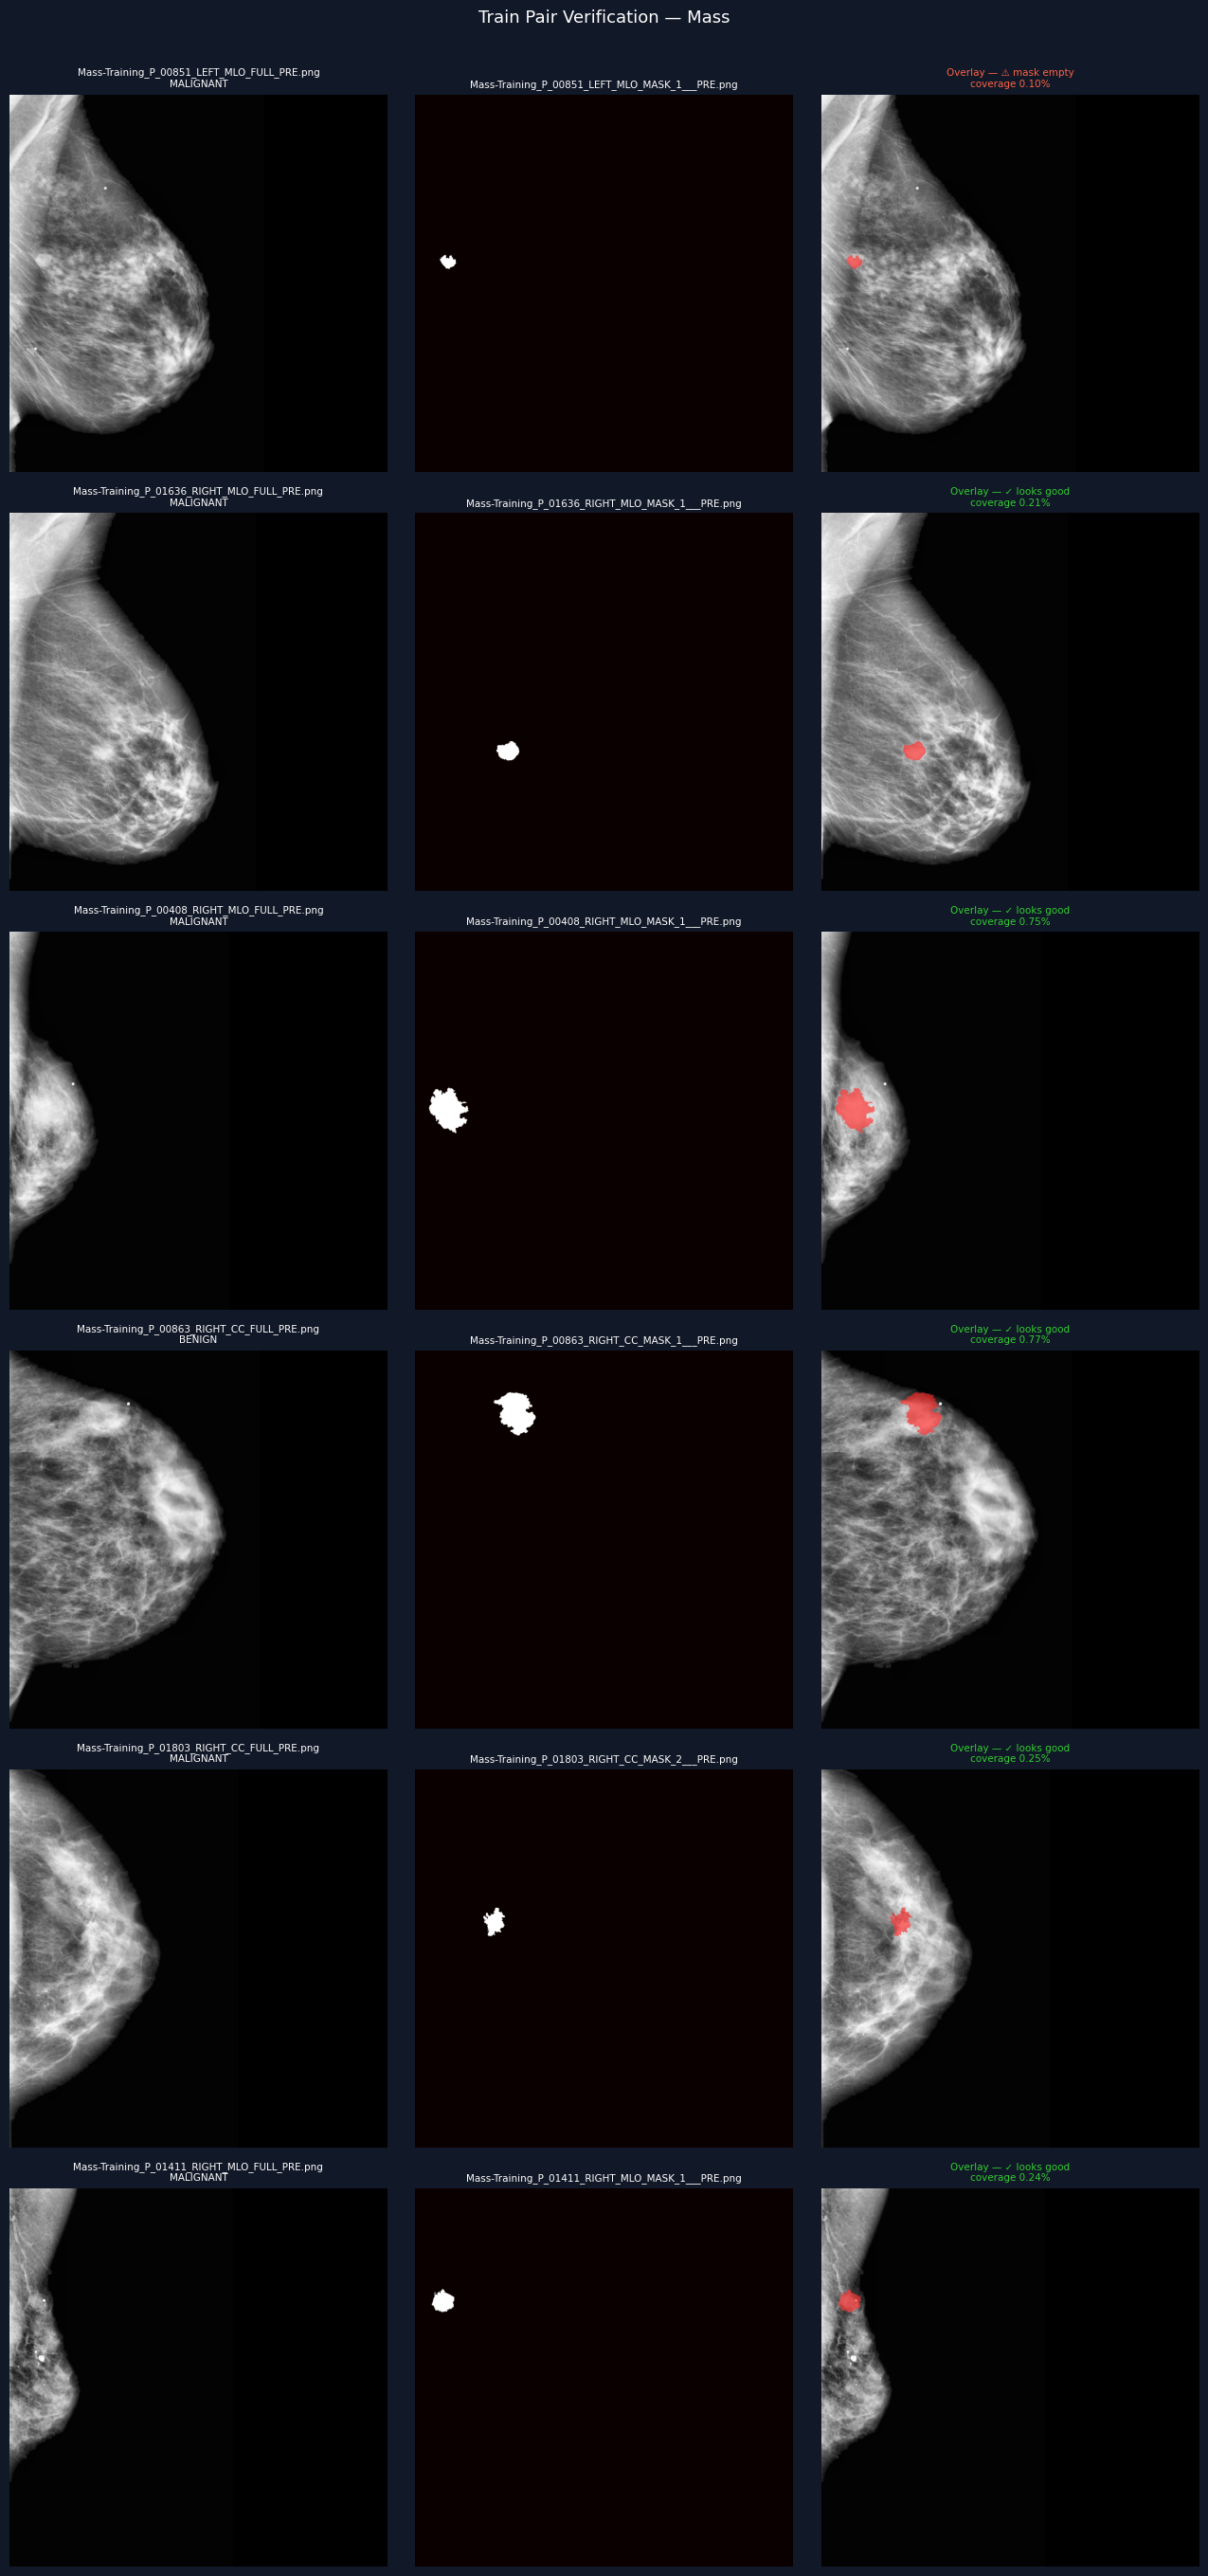

Saved → /kaggle/working/pair_verification.png


In [8]:
def verify_pairs(df, n=6, title="Pair Verification"):
    sample = df.sample(n=min(n, len(df)), random_state=42)
    fig, axes = plt.subplots(len(sample), 3, figsize=(13, 4.5 * len(sample)))
    fig.patch.set_facecolor("#111827")
    if len(sample) == 1:
        axes = [axes]

    for i, (_, row) in enumerate(sample.iterrows()):
        img    = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        mask   = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask_r = cv2.resize(mask, (img.shape[1], img.shape[0]))
        binary = mask_r > 127
        coverage = binary.sum() / binary.size

        overlay = img.astype(np.float32) / 255.0
        overlay[binary] = overlay[binary] * 0.35 + np.array([1.0, 0.15, 0.15]) * 0.65

        for ax in axes[i]:
            ax.axis("off")
            ax.set_facecolor("#111827")

        axes[i][0].imshow(img, cmap="gray")
        axes[i][0].set_title(
            f"{Path(row['image_path']).name}\n{row['label_name']}",
            color="white", fontsize=7.5
        )
        axes[i][1].imshow(mask, cmap="hot")
        axes[i][1].set_title(Path(row["mask_path"]).name, color="white", fontsize=7.5)

        flags = []
        if coverage < 0.001: flags.append("⚠ mask empty")
        if coverage > 0.25:   flags.append("⚠ mask >25% — check pairing")
        ok = not flags
        axes[i][2].imshow(np.clip(overlay, 0, 1))
        axes[i][2].set_title(
            f"Overlay — {'✓ looks good' if ok else '  '.join(flags)}\ncoverage {coverage:.2%}",
            color="limegreen" if ok else "tomato", fontsize=7.5
        )

    plt.suptitle(title, color="white", fontsize=13, y=1.005)
    plt.tight_layout()
    plt.savefig("/kaggle/working/pair_verification.png", dpi=130,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("Saved → /kaggle/working/pair_verification.png")

verify_pairs(df_train, n=6, title=f"Train Pair Verification — {CFG['abnormality']}")

In [9]:
from tqdm.notebook import tqdm

CACHE_DIR = "/kaggle/working/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def preprocess_and_cache(df, split_name):
    """
    Resizes all images and masks to IMG_SIZE and saves them as numpy arrays.
    Skips files that are already cached.
    Returns an updated DataFrame pointing to the cached files.
    """
    cached_image_paths = []
    cached_mask_paths  = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Caching {split_name}"):
        # Build cache filenames from the key
        safe_key   = row["key"].replace("/", "_").replace(" ", "_")
        img_cache  = os.path.join(CACHE_DIR, f"{safe_key}_img.npy")
        mask_cache = os.path.join(CACHE_DIR, f"{safe_key}_msk.npy")

        if not os.path.exists(img_cache):
            img = cv2.imread(row["image_path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            np.save(img_cache, img)

        if not os.path.exists(mask_cache):
            msk = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
            if msk.shape != (IMG_SIZE, IMG_SIZE):
                msk = cv2.resize(msk, (IMG_SIZE, IMG_SIZE),
                                 interpolation=cv2.INTER_NEAREST)
            msk = (msk > 127).astype(np.float32)
            np.save(mask_cache, msk)

        cached_image_paths.append(img_cache)
        cached_mask_paths.append(mask_cache)

    df = df.copy()
    df["image_path"] = cached_image_paths
    df["mask_path"]  = cached_mask_paths
    return df

df_train = preprocess_and_cache(df_train, "train")
df_test  = preprocess_and_cache(df_test,  "test")
print("Caching complete.")

Caching train:   0%|          | 0/1231 [00:00<?, ?it/s]

Caching test:   0%|          | 0/361 [00:00<?, ?it/s]

Caching complete.


In [10]:

train_ds = CBISDDSMDataset(df_train, transforms=get_train_transforms(), augment_fraction=0.3)
val_ds   = CBISDDSMDataset(df_test,  transforms=get_val_transforms(),   augment_fraction=0.0)

train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=True, 
    drop_last=True, persistent_workers=False,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=True,
    persistent_workers=True,
)

# Shape check
imgs, masks, labels = next(iter(train_loader))
print(f"Image batch : {imgs.shape}")    # [B, 3, 512, 512]
print(f"Mask  batch : {masks.shape}")   # [B, 1, 512, 512]
print(f"Label batch : {labels.shape}")  # [B]
print(f"Labels seen : {labels.unique().tolist()}  (0=benign 1=malignant)")

Image batch : torch.Size([32, 3, 320, 320])
Mask  batch : torch.Size([32, 1, 320, 320])
Label batch : torch.Size([32])
Labels seen : [0, 1]  (0=benign 1=malignant)


In [13]:

model = SegmentationUNet(encoder_name="resnet18", freeze_encoder=True).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_p:,}")
print(f"Trainable params : {trainable_p:,}  (encoder frozen for warmup)")
print(f"Model device : {next(model.parameters()).device}")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

[Model] Encoder FROZEN
Total params     : 19,108,817
Trainable params : 1,560,201  (encoder frozen for warmup)
Model device : cuda:0


In [15]:
scaler = torch.amp.GradScaler('cuda')

def run_epoch(model, loader, criterion, optimizer, train):
    if train and hasattr(loader.dataset, "reshuffle_augmentation"):
        loader.dataset.reshuffle_augmentation()
        print("reshuffled")
    model.train(train)
    totals = {"loss": 0.0, "dice": 0.0}
    n = 0

    with torch.set_grad_enabled(train):
        for images, masks, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.to(DEVICE,  non_blocking=True)

            if train:
                with torch.amp.autocast('cuda'):
                    seg_logit = model(images)
                    loss      = criterion(seg_logit, masks)
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with torch.amp.autocast('cuda'):
                    seg_logit = model(images)
                    loss      = criterion(seg_logit, masks)

            totals["loss"] += loss.item()
            totals["dice"] += dice_score(seg_logit, masks)
            n += 1

    return {k: v / max(n, 1) for k, v in totals.items()}


def train_phase(model, criterion, epochs, phase_name, best_dice, best_weights, history, epoch_offset=0):
    encoder_params = [p for p in model.unet.encoder.parameters() if p.requires_grad]
    other_params   = [p for p in model.parameters()
                      if p.requires_grad and id(p) not in {id(q) for q in encoder_params}]
    param_groups = [{"params": other_params, "lr": CFG["lr_head"]}]
    if encoder_params:
        param_groups.append({"params": encoder_params, "lr": CFG["lr_encoder"]})
    optimizer = AdamW(param_groups, weight_decay=CFG["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    print(f"\n{'═'*65}")
    print(f"  {phase_name}  ({epochs} epochs)")
    print(f"{'═'*65}")

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, criterion, optimizer, train=True)
        vl = run_epoch(model, val_loader,   criterion, None,      train=False)
        scheduler.step()

        history.append({
            "epoch": epoch + epoch_offset,   # ← continuous x-axis
            "phase": phase_name,
            **{f"tr_{k}": v for k, v in tr.items()},
            **{f"vl_{k}": v for k, v in vl.items()},
        })

        print(
            f"Ep {epoch + epoch_offset:03d}  "
            f"Tr[loss={tr['loss']:.4f}  dice={tr['dice']:.4f}]  "
            f"Vl[loss={vl['loss']:.4f}  dice={vl['dice']:.4f}]  "
            f"({time.time()-t0:.1f}s)"
        )
        if vl["dice"] > best_dice:
            best_dice    = vl["dice"]
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, CFG["save_path"])
            print(f"  ✓ New best Dice={best_dice:.4f}  saved → {CFG['save_path']}")

    return best_dice, best_weights

In [16]:
best_dice    = 0.0
best_weights = None
history      = []

best_dice, best_weights = train_phase(
    model, criterion,
    epochs       = CFG["warmup_epochs"],
    phase_name   = "Phase 1 — Warmup (frozen encoder)",
    best_dice    = 0.0,
    best_weights = None,
    history      = history,
    epoch_offset = 0,
)



═════════════════════════════════════════════════════════════════
  Phase 1 — Warmup (frozen encoder)  (15 epochs)
═════════════════════════════════════════════════════════════════
reshuffled
Ep 001  Tr[loss=0.8327  dice=0.0370]  Vl[loss=0.8356  dice=0.0056]  (30.7s)
  ✓ New best Dice=0.0056  saved → /kaggle/working/mass_best_model.pth
reshuffled
Ep 002  Tr[loss=0.7097  dice=0.1768]  Vl[loss=0.7174  dice=0.2716]  (27.1s)
  ✓ New best Dice=0.2716  saved → /kaggle/working/mass_best_model.pth
reshuffled
Ep 003  Tr[loss=0.6387  dice=0.1976]  Vl[loss=0.6402  dice=0.2723]  (27.3s)
  ✓ New best Dice=0.2723  saved → /kaggle/working/mass_best_model.pth
reshuffled
Ep 004  Tr[loss=0.5941  dice=0.2285]  Vl[loss=0.5887  dice=0.2490]  (27.2s)
reshuffled
Ep 005  Tr[loss=0.5670  dice=0.2256]  Vl[loss=0.5616  dice=0.2452]  (27.1s)
reshuffled
Ep 006  Tr[loss=0.5471  dice=0.2518]  Vl[loss=0.5404  dice=0.3211]  (27.1s)
  ✓ New best Dice=0.3211  saved → /kaggle/working/mass_best_model.pth
reshuffled
Ep 00

In [17]:
model.unfreeze_encoder()

# Phase 2 — offset by warmup epochs so graph is continuous
best_dice, best_weights = train_phase(
    model, criterion,
    epochs       = CFG["finetune_epochs"],
    phase_name   = "Phase 2 — Fine-tune (end-to-end)",
    best_dice    = best_dice,
    best_weights = best_weights,
    history      = history,
    epoch_offset = CFG["warmup_epochs"],   # ← epochs 21–60 instead of 1–40
)


[Model] Encoder UNFROZEN — fine-tuning end-to-end

═════════════════════════════════════════════════════════════════
  Phase 2 — Fine-tune (end-to-end)  (45 epochs)
═════════════════════════════════════════════════════════════════
reshuffled
Ep 016  Tr[loss=0.4861  dice=0.2889]  Vl[loss=0.4595  dice=0.2997]  (41.1s)
reshuffled
Ep 017  Tr[loss=0.4570  dice=0.3253]  Vl[loss=0.4491  dice=0.2872]  (41.0s)
reshuffled
Ep 018  Tr[loss=0.4338  dice=0.3436]  Vl[loss=0.4166  dice=0.3584]  (40.9s)
  ✓ New best Dice=0.3584  saved → /kaggle/working/mass_best_model.pth
reshuffled
Ep 019  Tr[loss=0.4108  dice=0.3672]  Vl[loss=0.3997  dice=0.3920]  (40.8s)
  ✓ New best Dice=0.3920  saved → /kaggle/working/mass_best_model.pth
reshuffled
Ep 020  Tr[loss=0.3969  dice=0.3799]  Vl[loss=0.3961  dice=0.4133]  (40.8s)
  ✓ New best Dice=0.4133  saved → /kaggle/working/mass_best_model.pth
reshuffled
Ep 021  Tr[loss=0.3791  dice=0.4102]  Vl[loss=0.4108  dice=0.3968]  (40.9s)
reshuffled
Ep 022  Tr[loss=0.3690  di

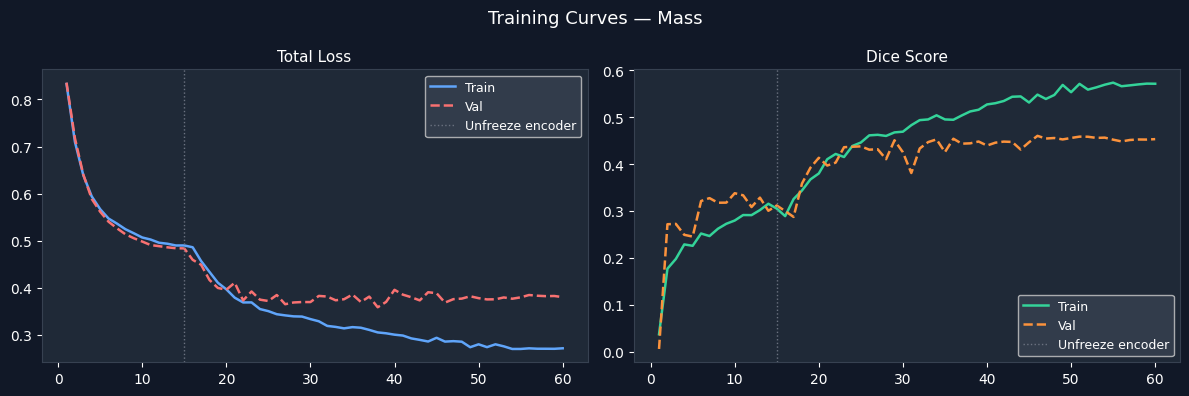

In [18]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#111827")

for ax in axes:
    ax.set_facecolor("#1f2937")
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#374151")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color("white")

plots = [
    ("loss", "Total Loss", "#60a5fa", "#f87171"),
    ("dice", "Dice Score", "#34d399", "#fb923c"),
]
for ax, (metric, title, c_tr, c_vl) in zip(axes, plots):
    ax.plot(df_hist["epoch"], df_hist[f"tr_{metric}"], color=c_tr, lw=1.8, label="Train")
    ax.plot(df_hist["epoch"], df_hist[f"vl_{metric}"], color=c_vl, lw=1.8, ls="--", label="Val")
    ax.axvline(x=CFG["warmup_epochs"], color="#6b7280", lw=1, ls=":", label="Unfreeze encoder")
    ax.set_title(title, color="white", fontsize=11)
    ax.legend(facecolor="#374151", labelcolor="white", fontsize=9)

plt.suptitle(f"Training Curves — {CFG['abnormality']}", color="white", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=130,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [19]:
model.load_state_dict(torch.load(CFG["save_path"], map_location=DEVICE))
model.eval()

dice_scores = []

with torch.no_grad():
    for images, masks, labels in val_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        with torch.amp.autocast('cuda'):
            seg_logit = model(images)
        dice_scores.append(dice_score(seg_logit, masks))

print(f"Mean Dice Score : {np.mean(dice_scores):.4f}")
print(f"Min  Dice Score : {np.min(dice_scores):.4f}")
print(f"Max  Dice Score : {np.max(dice_scores):.4f}")

Mean Dice Score : 0.4601
Min  Dice Score : 0.3630
Max  Dice Score : 0.5217


In [23]:
import cv2

def filter_small_components(pred_mask, min_size_ratio=0.30):
    """
    Takes a binary predicted mask (H, W) as a numpy bool/float array.
    Finds all connected components, keeps only those whose area is at
    least min_size_ratio * area of the largest component.
    
    e.g. min_size_ratio=0.30 removes anything less than 30% the size
    of the largest detected region.
    
    Returns a cleaned binary mask (H, W) as float32.
    """
    # cv2 needs uint8
    mask_uint8 = (pred_mask > 0.5).astype(np.uint8)
    
    # Find connected components
    # num_labels includes background (label 0), so real regions start at 1
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask_uint8, connectivity=8
    )
    
    if num_labels <= 1:
        # Nothing detected at all
        return mask_uint8.astype(np.float32)
    
    # stats[label, cv2.CC_STAT_AREA] gives pixel count for each component
    # Skip index 0 (background)
    areas = stats[1:, cv2.CC_STAT_AREA]  # areas for real components only
    largest_area = areas.max()
    threshold_area = largest_area * min_size_ratio
    
    # Build cleaned mask — only keep components large enough
    cleaned = np.zeros_like(mask_uint8)
    for label_idx, area in enumerate(areas, start=1):
        if area >= threshold_area:
            cleaned[labels == label_idx] = 1
    
    return cleaned.astype(np.float32)

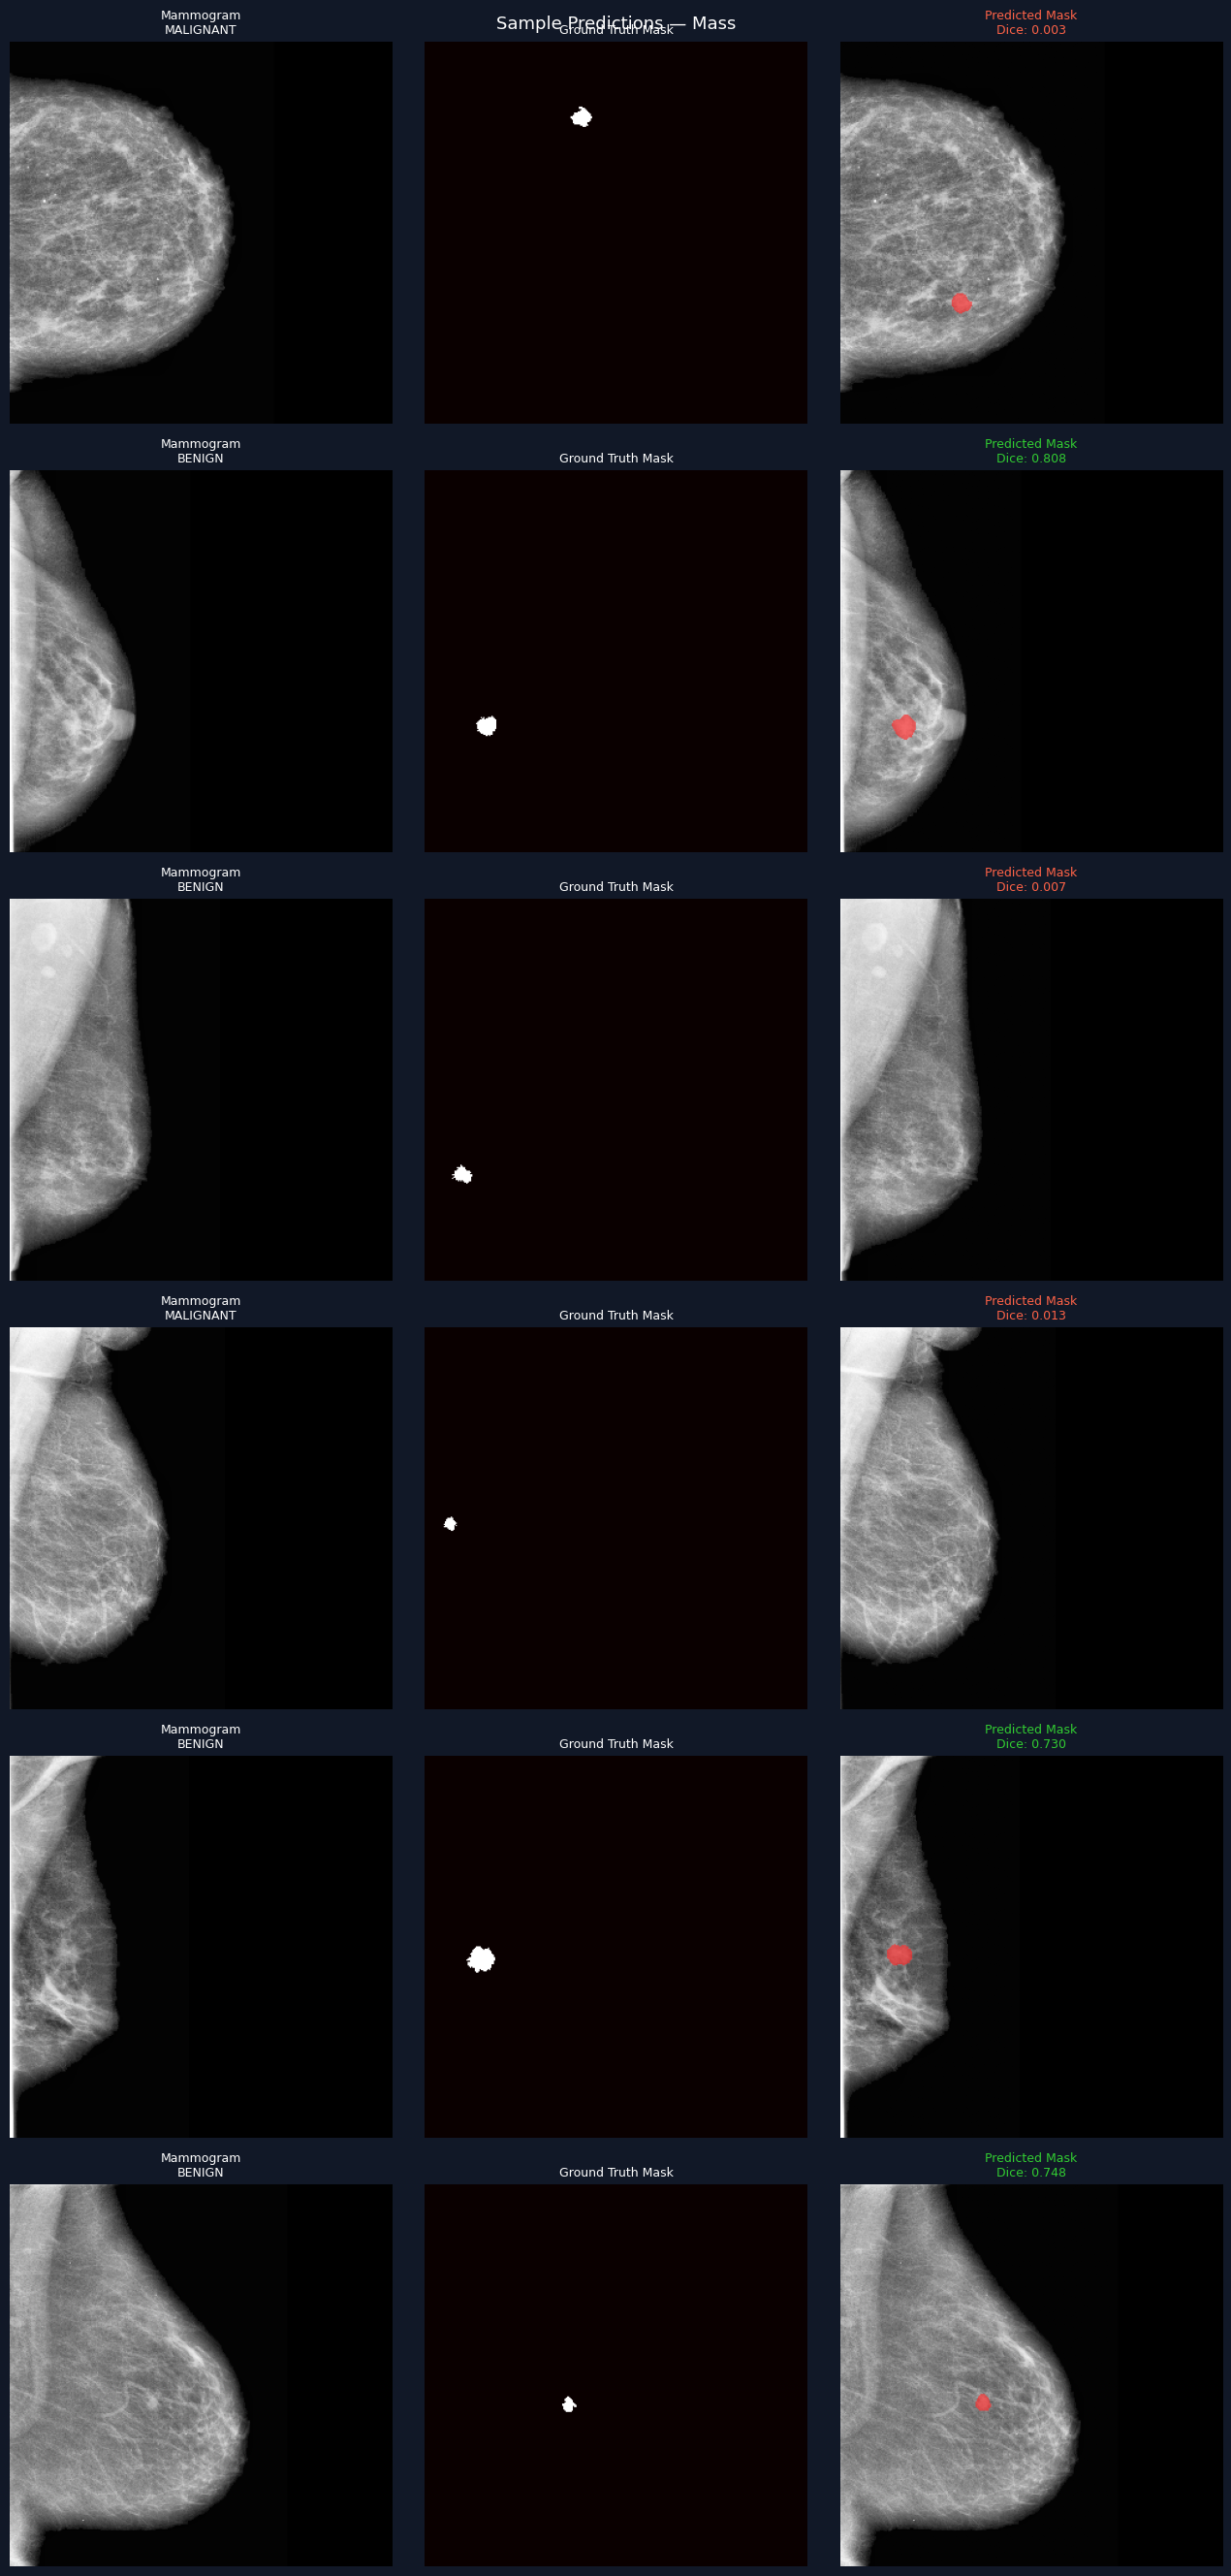

In [24]:
def show_predictions(model, df, n=6):
    sample     = df.sample(n=min(n, len(df)))
    transforms = get_val_transforms()

    fig, axes = plt.subplots(len(sample), 3, figsize=(13, 4.5 * len(sample)))
    fig.patch.set_facecolor("#111827")
    if len(sample) == 1:
        axes = [axes]

    model.eval()
    for i, (_, row) in enumerate(sample.iterrows()):
        # Load from cache (.npy files)
        raw = np.load(row["image_path"])                    # uint8 [H, W, 3]
        gt  = np.load(row["mask_path"])                     # float32 [H, W]

        tensor = transforms(image=raw)["image"].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                seg_logit = model(tensor)

        pred_mask = (torch.sigmoid(seg_logit) > 0.5).squeeze().cpu().numpy()
        pred_mask = filter_small_components(pred_mask, min_size_ratio=0.30)

        gt_tensor = torch.from_numpy(gt).unsqueeze(0).unsqueeze(0).to(DEVICE)
        d_score   = dice_score(seg_logit, gt_tensor)

        overlay = raw.astype(np.float32) / 255.0
        overlay[pred_mask == 1] = overlay[pred_mask == 1] * 0.35 + np.array([1., 0.15, 0.15]) * 0.65

        for ax in axes[i]:
            ax.axis("off")
            ax.set_facecolor("#111827")

        axes[i][0].imshow(raw, cmap="gray")
        label_str = "BENIGN" if row["label"] == 0 else "MALIGNANT"
        axes[i][0].set_title("Mammogram\n" + label_str, color="white", fontsize=9)

        axes[i][1].imshow(gt, cmap="hot")
        axes[i][1].set_title("Ground Truth Mask", color="white", fontsize=9)

        axes[i][2].imshow(np.clip(overlay, 0, 1))
        axes[i][2].set_title(
            f"Predicted Mask\nDice: {d_score:.3f}",
            color="limegreen" if d_score > 0.5 else "tomato", fontsize=9
        )

    plt.suptitle(f"Sample Predictions — {CFG['abnormality']}", color="white", fontsize=13)
    plt.tight_layout()
    plt.savefig("/kaggle/working/predictions.png", dpi=130,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

show_predictions(model, df_test, n=6)

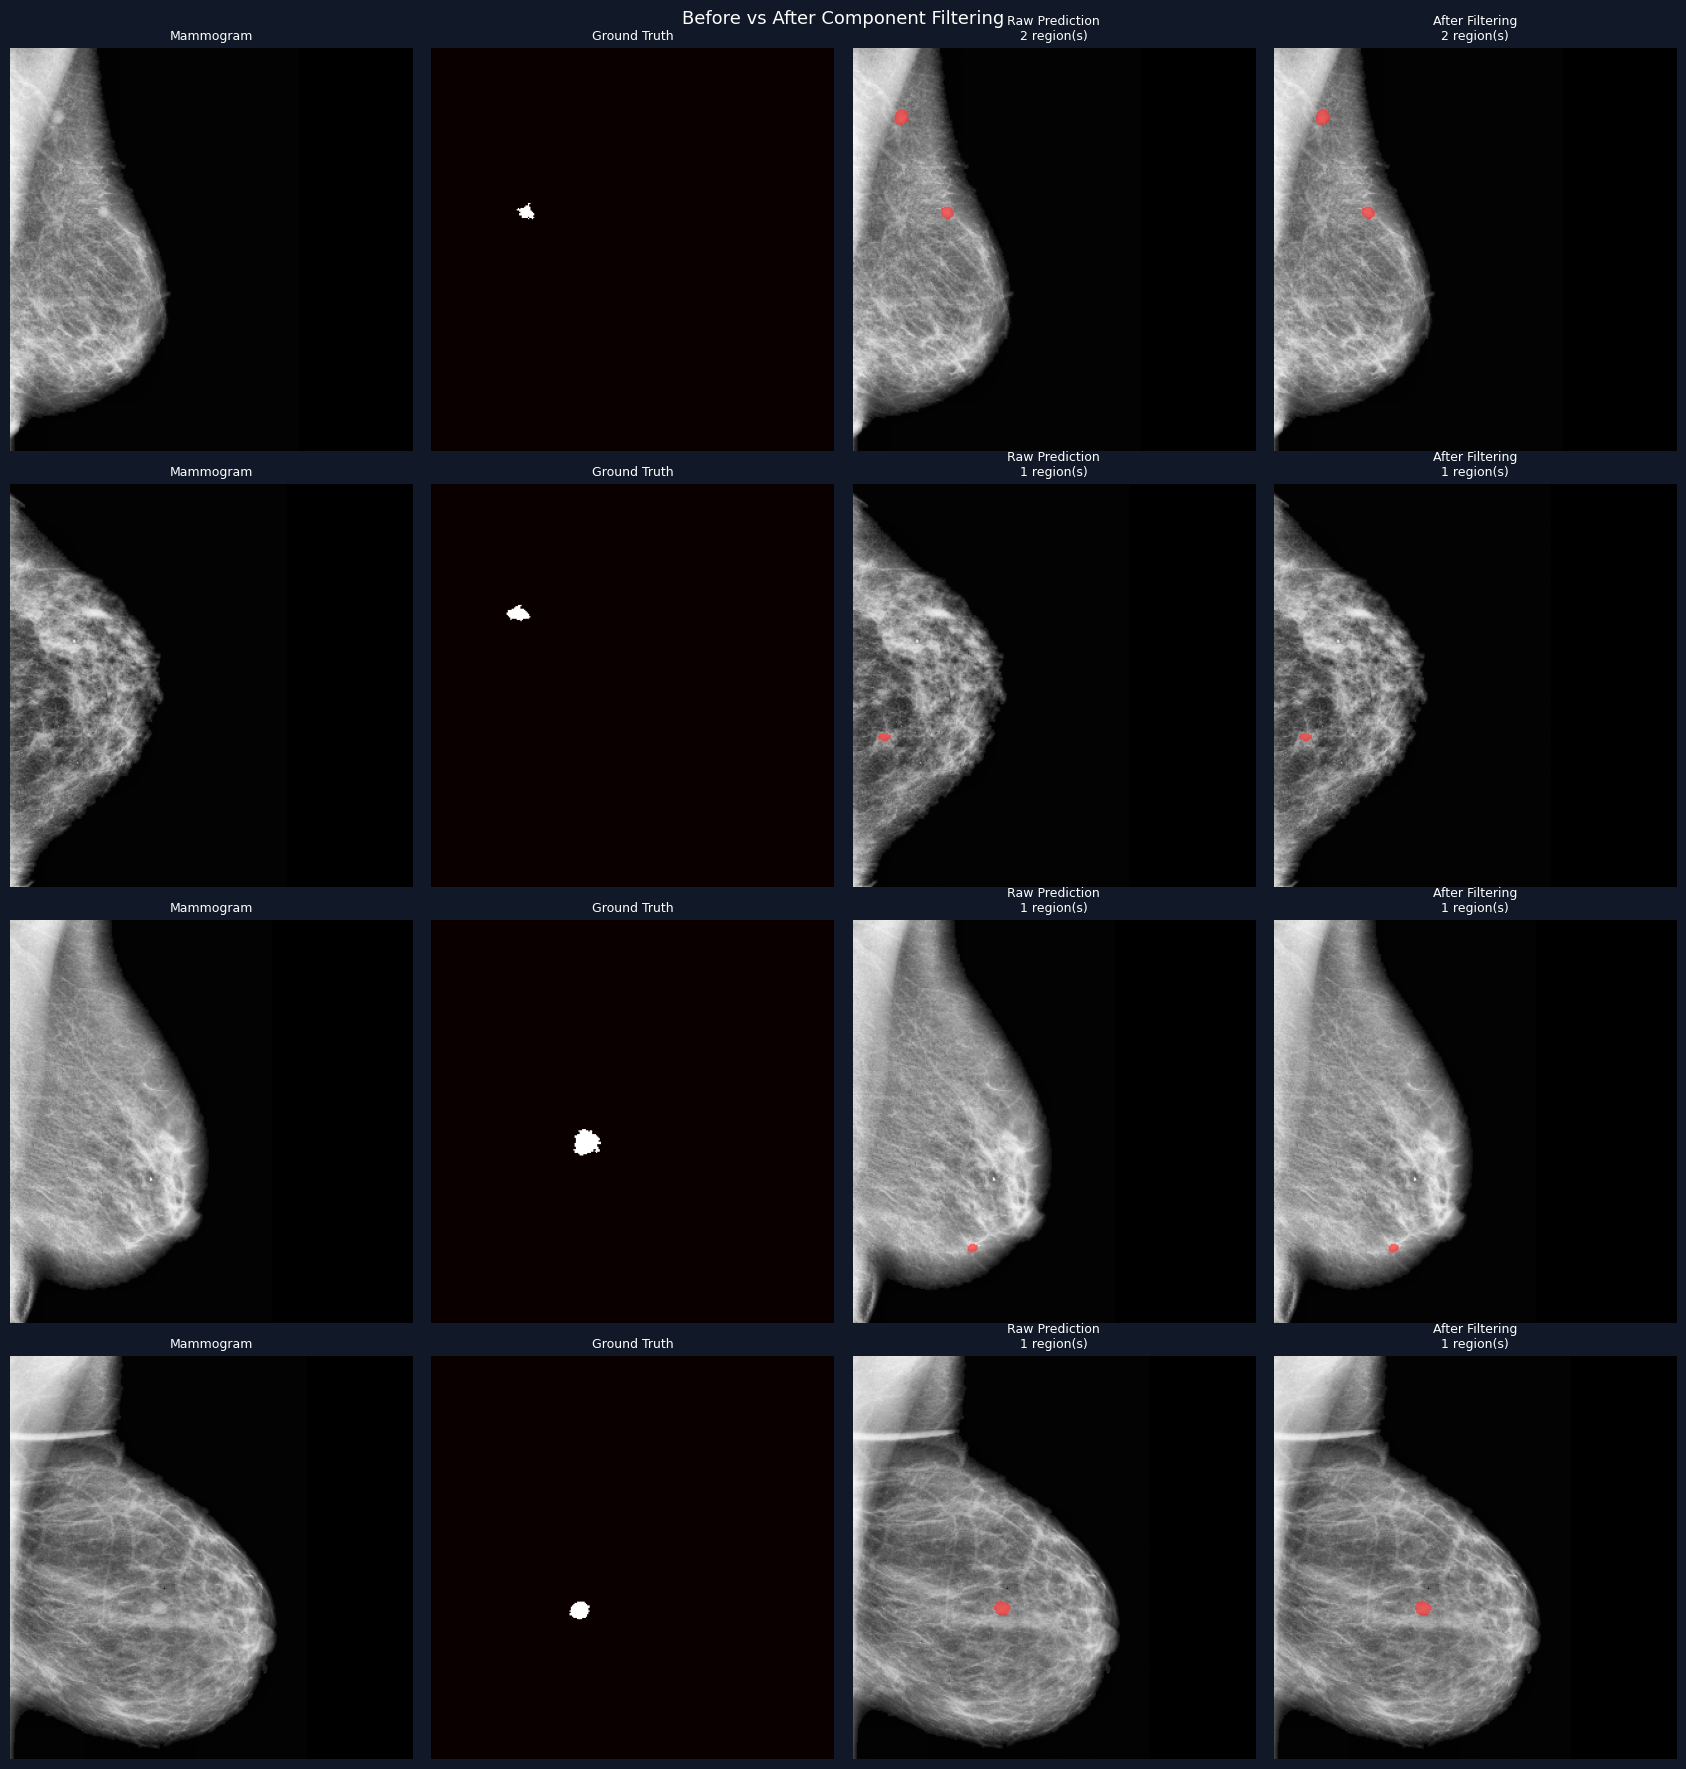

In [25]:
def show_predictions_compare(model, df, n=4):
    sample     = df.sample(n=min(n, len(df)))
    transforms = get_val_transforms()

    fig, axes = plt.subplots(len(sample), 4, figsize=(17, 4.5 * len(sample)))
    fig.patch.set_facecolor("#111827")
    if len(sample) == 1:
        axes = [axes]

    model.eval()
    for i, (_, row) in enumerate(sample.iterrows()):
        raw = np.load(row["image_path"])
        gt  = np.load(row["mask_path"])

        tensor = transforms(image=raw)["image"].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                seg_logit = model(tensor)

        raw_mask      = (torch.sigmoid(seg_logit) > 0.5).squeeze().cpu().numpy()
        filtered_mask = filter_small_components(raw_mask, min_size_ratio=0.30)

        overlay_raw = raw.astype(np.float32) / 255.0
        overlay_raw[raw_mask == 1] = overlay_raw[raw_mask == 1] * 0.35 + np.array([1., 0.15, 0.15]) * 0.65

        overlay_filtered = raw.astype(np.float32) / 255.0
        overlay_filtered[filtered_mask == 1] = overlay_filtered[filtered_mask == 1] * 0.35 + np.array([1., 0.15, 0.15]) * 0.65

        for ax in axes[i]:
            ax.axis("off")
            ax.set_facecolor("#111827")

        axes[i][0].imshow(raw, cmap="gray")
        axes[i][0].set_title("Mammogram", color="white", fontsize=9)

        axes[i][1].imshow(gt, cmap="hot")
        axes[i][1].set_title("Ground Truth", color="white", fontsize=9)

        axes[i][2].imshow(np.clip(overlay_raw, 0, 1))
        n_components = cv2.connectedComponentsWithStats((raw_mask > 0.5).astype(np.uint8), connectivity=8)[0] - 1
        axes[i][2].set_title(f"Raw Prediction\n{n_components} region(s)", color="white", fontsize=9)

        axes[i][3].imshow(np.clip(overlay_filtered, 0, 1))
        n_kept = cv2.connectedComponentsWithStats((filtered_mask > 0.5).astype(np.uint8), connectivity=8)[0] - 1
        axes[i][3].set_title(f"After Filtering\n{n_kept} region(s)", color="white", fontsize=9)

    plt.suptitle("Before vs After Component Filtering", color="white", fontsize=13)
    plt.tight_layout()
    plt.savefig("/kaggle/working/filtering_comparison.png", dpi=130,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

show_predictions_compare(model, df_test, n=4)